# 05 — DOM and Métropole: Hydrometric Coverage

**Question:** Is real-time hydrometric data (`observations_tr`) as available and fresh
in France's overseas departments (DOM) as in metropolitan France?

**Method:** Sample active stations from every French department (96 metro + 5 DOM),
run `data_coverage()` on each, compare the activation rate of `observations_tr`.

**DOM:** 971 Guadeloupe · 972 Martinique · 973 Guyane · 974 Réunion · 976 Mayotte

Data is cached to `data/coverage_dom_metro.csv` — delete the file and re-run cell 2 to refresh.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import subprocess
import sys

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

REPO_ROOT = Path.cwd().parent  # notebooks/ → repo root
SCRIPT_PATH = REPO_ROOT / "scripts" / "hydrometrie" / "coverage_sampling.py"
CACHE_PATH = REPO_ROOT / "data" / "coverage_dom_metro.csv"

N_STATIONS = 20

DOM_DEPS = ["971", "972", "973", "974", "976"]
DOM_LABELS = {
    "971": "Guadeloupe",
    "972": "Martinique",
    "973": "Guyane",
    "974": "Réunion",
    "976": "Mayotte",
}


## Data sampling

The sampling script fetches active stations for all 101 departments and runs
`data_coverage()` on each (~1900 stations, ~10 minutes).

**Option A — run from the notebook** (requires keeping the browser open):
execute the cell below. Progress is streamed inline.

**Option B — run from the terminal** (recommended for long runs):
```bash
uv run python scripts/hydrometrie/coverage_sampling.py
# custom output path or station count:
uv run python scripts/hydrometrie/coverage_sampling.py --n-stations 20 --output data/coverage_dom_metro.csv
```
Then come back and execute the cell below to load the cache.

In [2]:
# If CACHE_PATH exists (generated via terminal), this cell is a no-op.
if CACHE_PATH.exists():
    print(f"Cache found at {CACHE_PATH} — skipping sampling.")
    print("Delete the file and re-run this cell to refresh.")
else:
    print(f"No cache found — running {SCRIPT_PATH}")
    print("This may take 30 minutes. Progress below:\n")
    proc = subprocess.Popen(
        [sys.executable, str(SCRIPT_PATH), "--n-stations", str(N_STATIONS)],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"Sampling script failed with exit code {proc.returncode}")
    print("\nSampling complete.")

Cache found at /home/pierre/src/hubeau-lab/data/coverage_dom_metro.csv — skipping sampling.
Delete the file and re-run this cell to refresh.


In [3]:
df = pd.read_csv(CACHE_PATH)
print(f"{len(df)} rows · {df['code_station'].nunique()} stations · {df['dep'].nunique()} departments")

df["active"] = (df["count"].fillna(0) > 0).astype(int)
df["latest_dt"] = pd.to_datetime(df["latest"], utc=True, errors="coerce")
now = datetime.now(timezone.utc)
df["staleness_days"] = (now - df["latest_dt"]).dt.days
df["fresh_24h"] = (df["staleness_days"] <= 1).astype(int)

dep_summary = (
    df.groupby(["dep", "zone", "label"])
    .agg(
        n_stations=("code_station", "count"),
        active_rate=("active", "mean"),
        fresh_24h_rate=("fresh_24h", "mean"),
        median_staleness=("staleness_days", "median"),
    )
    .reset_index()
)

print("\n=== Global summary ===")
print(df.groupby("zone")[["active", "fresh_24h"]].mean().round(3))

1930 rows · 1930 stations · 101 departments

=== Global summary ===
           active  fresh_24h
zone                        
DOM         0.550      0.450
Metropole   0.814      0.793


## 1 — Activation rate by department

A station is **active** if `observations_tr` returns `count > 0`.  
Blue = metropolitan France · Orange = DOM.

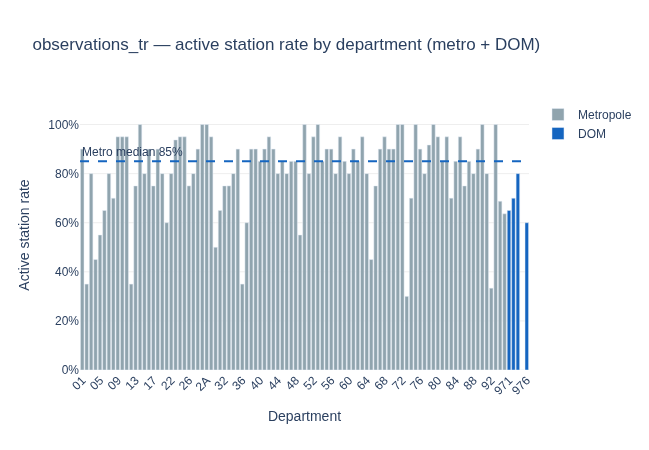

In [4]:
color_map = {"Metropole": "#90A4AE", "DOM": "#1565C0"}

metro_sorted = dep_summary[dep_summary["zone"] == "Metropole"].sort_values("dep")
dom_sorted = dep_summary[dep_summary["zone"] == "DOM"].sort_values("dep")
plot_df = pd.concat([metro_sorted, dom_sorted])
metro_median = metro_sorted["active_rate"].median()

fig = px.bar(
    plot_df,
    x="dep",
    y="active_rate",
    color="zone",
    color_discrete_map=color_map,
    hover_data={"label": True, "n_stations": True, "active_rate": ":.0%"},
    labels={"dep": "Department", "active_rate": "Active station rate", "zone": "Zone"},
    title="observations_tr — active station rate by department (metro + DOM)",
)
fig.add_hline(
    y=metro_median,
    line_dash="dash",
    line_color="#1565C0",
    annotation_text=f"Metro median {metro_median:.0%}",
    annotation_position="top left",
)
fig.update_layout(
    yaxis_tickformat=".0%",
    yaxis_range=[0, 1.1],
    xaxis_tickangle=-45,
    height=450,
    legend_title_text="",
    plot_bgcolor="white",
    yaxis=dict(gridcolor="#eee"),
)
fig.show()

## 2 — Geographic map: active vs inactive stations

Each dot is a sampled station.  
**Blue = active** (`count > 0`) · **Red = inactive** (`count = 0`).  
Stations without coordinates are excluded.

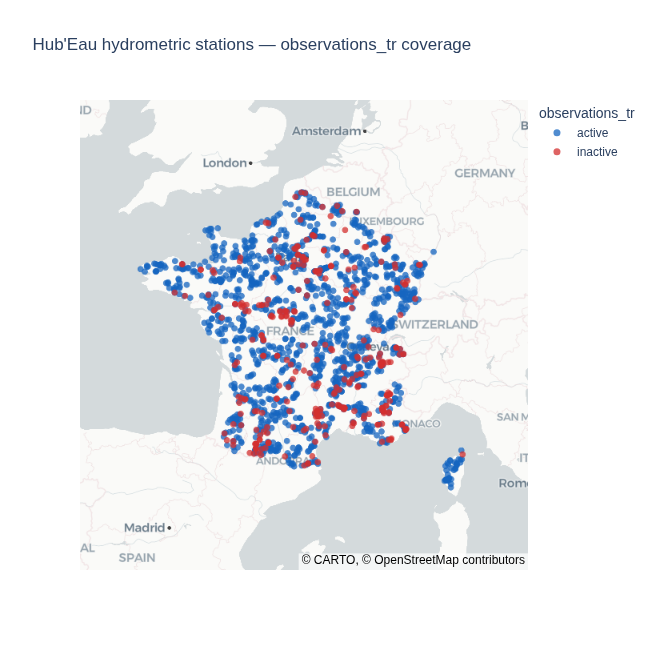

In [5]:
map_df = df.dropna(subset=["latitude", "longitude"]).copy()
map_df["status"] = map_df["active"].map({1: "active", 0: "inactive"})

fig_map = px.scatter_map(  # Remplacement effectué ici
    map_df,
    lat="latitude",
    lon="longitude",
    color="status",
    color_discrete_map={"active": "#1565C0", "inactive": "#D32F2F"},
    hover_name="libelle_station",
    hover_data={
        "code_station": True,
        "dep": True,
        "count": True,
        "latest": True,
        "latitude": False,
        "longitude": False,
        "status": False,
    },
    zoom=4,
    center={"lat": 46.5, "lon": 2.5},
    height=650,
    title="Hub'Eau hydrometric stations — observations_tr coverage",
    map_style="carto-positron",  # Notez le changement de paramètre ici
    opacity=0.75,
)
fig_map.update_traces(marker=dict(size=7))
fig_map.update_layout(legend_title_text="observations_tr")
fig_map.show()

## 3 — Freshness: days since latest observation (active stations only)

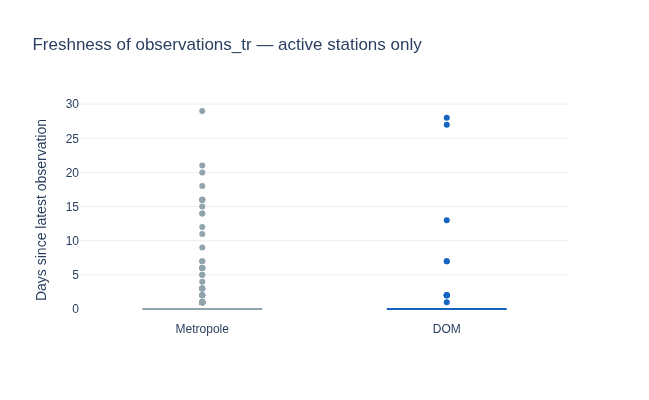

In [6]:
active_df = df[(df["active"] == 1) & df["staleness_days"].notna()].copy()

fig_box = px.box(
    active_df,
    x="zone",
    y="staleness_days",
    color="zone",
    color_discrete_map=color_map,
    points="outliers",
    hover_data={"code_station": True, "dep": True},
    labels={"staleness_days": "Days since latest observation", "zone": ""},
    title="Freshness of observations_tr — active stations only",
)
fig_box.update_layout(
    showlegend=False,
    plot_bgcolor="white",
    yaxis=dict(gridcolor="#eee"),
    height=400,
)
fig_box.show()

## 4 — DOM detail: per-island breakdown vs metropolitan median

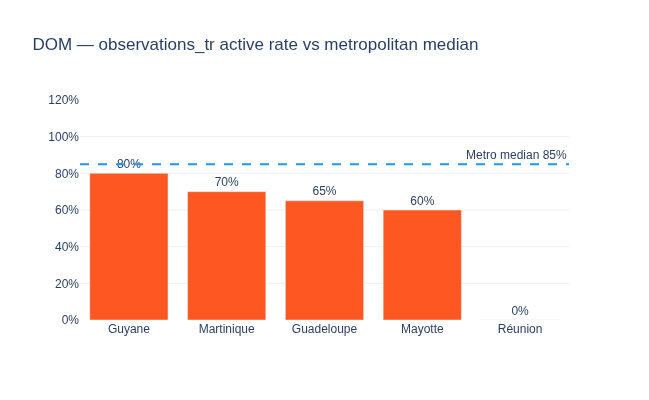

     label  n_stations  active_rate  fresh_24h_rate
    Guyane          20         0.80            0.75
Martinique          20         0.70            0.70
Guadeloupe          20         0.65            0.25
   Mayotte          20         0.60            0.55
   Réunion          20         0.00            0.00


In [7]:
dom_detail = (
    dep_summary[dep_summary["zone"] == "DOM"]
    .sort_values("active_rate", ascending=False)
    .copy()
)

fig_dom = go.Figure()
fig_dom.add_trace(
    go.Bar(
        x=dom_detail["label"],
        y=dom_detail["active_rate"],
        marker_color=[
            "#FF9800" if r >= metro_median else "#FF5722"
            for r in dom_detail["active_rate"]
        ],
        text=[f"{r:.0%}" for r in dom_detail["active_rate"]],
        textposition="outside",
        hovertemplate="%{x}<br>Active rate: %{y:.0%}<extra></extra>",
    )
)
fig_dom.add_hline(
    y=metro_median,
    line_dash="dash",
    line_color="#2196F3",
    annotation_text=f"Metro median {metro_median:.0%}",
    annotation_position="top right",
)
fig_dom.update_layout(
    title="DOM — observations_tr active rate vs metropolitan median",
    yaxis_tickformat=".0%",
    yaxis_range=[0, 1.2],
    plot_bgcolor="white",
    yaxis=dict(gridcolor="#eee"),
    height=400,
    showlegend=False,
)
fig_dom.show()

print(dom_detail[["label", "n_stations", "active_rate", "fresh_24h_rate"]].to_string(index=False))

## 5 — Metropolitan gaps: departments below 50% activation

7 metropolitan departments below 50%:
dep  active_rate  n_stations
 73     0.300000          20
 92     0.333333           3
 02     0.350000          20
 12     0.350000          20
 36     0.350000          20
 04     0.450000          20
 65     0.450000          20


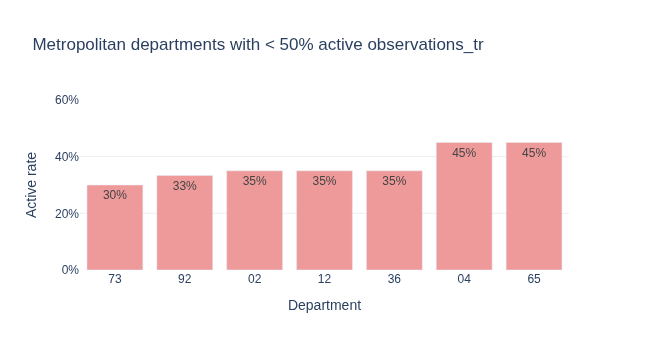

In [8]:
metro_gaps = dep_summary[
    (dep_summary["zone"] == "Metropole") & (dep_summary["active_rate"] < 0.5)
].sort_values("active_rate")

if metro_gaps.empty:
    print("No metropolitan department below 50% — coverage looks uniform.")
else:
    print(f"{len(metro_gaps)} metropolitan departments below 50%:")
    print(metro_gaps[["dep", "active_rate", "n_stations"]].to_string(index=False))

    fig_gaps = px.bar(
        metro_gaps,
        x="dep",
        y="active_rate",
        text=[f"{r:.0%}" for r in metro_gaps["active_rate"]],
        color_discrete_sequence=["#EF9A9A"],
        labels={"dep": "Department", "active_rate": "Active rate"},
        title="Metropolitan departments with < 50% active observations_tr",
    )
    fig_gaps.update_layout(
        yaxis_tickformat=".0%",
        yaxis_range=[0, 0.6],
        plot_bgcolor="white",
        yaxis=dict(gridcolor="#eee"),
        height=350,
    )
    fig_gaps.show()

## Summary

**Key findings:**
- 974 (Réunion) and 976 (Mayotte) show near-zero real-time coverage in this sample.
- 971 (Guadeloupe), 972 (Martinique), and 973 (Guyane) are broadly comparable to mid-range metropolitan departments.
- Metropolitan coverage is not uniform — some departments have significant gaps.
- `obs_elab` (daily/monthly aggregates) was excluded: timestamps show it is no longer actively updated.

**Data source:** Hub'Eau API v2 · `hubeau-data` client · 20 active stations sampled per department.